In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

In [2]:
coloc_gdf = gpd.read_parquet("orcestra_coloc_ec_sounders.parquet")

In [3]:
overpass_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass"
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [11]:
coloc_gdf = coloc_gdf.loc[[
    int(f.stem.split("_")[1])
    for f in overpass_files
]]

In [63]:
coloc_gdf["overpass_file"] = [str(f) for f in overpass_files]

In [19]:
xr.open_datatree(coloc_gdf.overpass_file[0]).noaa_20.obs_time_tai93.mean()

<xarray.DataArray 'obs_time_tai93' ()> Size: 8B
array('2024-08-10T20:37:09.348236846', dtype='datetime64[ns]')

In [26]:
def get_mean_times(filename):
    with xr.open_datatree(filename) as dt:
        return [
            pd.to_datetime(dt.ACM_CAP_2B.time.mean().values),
            pd.to_datetime(dt.noaa_20.obs_time_tai93.mean().values),
            pd.to_datetime(dt.snpp.obs_time_tai93.mean().values)
        ]

In [29]:
mean_times = [
    get_mean_times(f) for f in coloc_gdf["overpass_file"]
]

In [36]:
coloc_gdf = coloc_gdf.join(
    pd.DataFrame(
        mean_times,
        columns=["mean_time_ec", "mean_time_noaa_20", "mean_time_snpp"],
        index=coloc_gdf.index
    )
)

In [38]:
coloc_gdf["ec_time_offset"] = coloc_gdf.mean_time_ec - (coloc_gdf.time - coloc_gdf.time_cell)
coloc_gdf["noaa_20_time_offset"] = coloc_gdf.mean_time_noaa_20 - (coloc_gdf.time - coloc_gdf.time_cell)
coloc_gdf["snpp_time_offset"] = coloc_gdf.mean_time_snpp - (coloc_gdf.time - coloc_gdf.time_cell)

In [40]:
coloc_gdf

,index_coloc,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,...,end_time_snpp,time_diff_n20,time_diff_snpp,overpass_file,mean_time_ec,mean_time_noaa_20,mean_time_snpp,ec_time_offset,noaa_20_time_offset,snpp_time_offset
0,35492,41,1289,2589.0,520.30,10,20,25.310354,35493,2024-08-10 20:30:00,...,2024-08-10 20:18:00,-1 days +23:54:32,0 days 00:18:32,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-08-10 20:39:32.527589577,2024-08-10 20:37:09.348236846,2024-08-10 20:13:06.170131565,0 days 00:09:32.527589577,0 days 00:07:09.348236846,-1 days +23:43:06.170131565
1,35675,42,155,750.0,662.00,1,5,5.148579,35676,2024-08-10 21:00:00,...,2024-08-10 19:36:00,0 days 01:11:00,0 days 01:35:00,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-08-10 21:15:54.413262774,2024-08-10 19:57:42.376306088,2024-08-10 19:33:42.204650995,0 days 00:15:54.413262774,-1 days +22:57:42.376306088,-1 days +22:33:42.204650995
2,36208,42,945,745.0,638.00,1,10,11.937240,36209,2024-08-10 21:00:00,...,2024-08-10 19:36:00,0 days 01:11:00,0 days 01:35:00,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-08-10 21:16:12.055949200,2024-08-10 19:57:04.437163871,2024-08-10 19:33:05.466349693,0 days 00:16:12.055949200,-1 days +22:57:04.437163871,-1 days +22:33:05.466349693
3,68260,78,704,3384.0,664.50,4,5,6.894357,68261,2024-08-11 15:00:00,...,2024-08-11 14:48:00,0 days 00:07:22,0 days 00:31:22,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-08-11 15:14:29.029914484,2024-08-11 15:09:45.090144641,2024-08-11 14:45:39.947283002,0 days 00:14:29.029914484,0 days 00:09:45.090144641,-1 days +23:45:39.947283002
4,71473,82,221,1319.0,557.00,5,5,6.455366,71474,2024-08-11 17:00:00,...,2024-08-11 15:54:00,0 days 01:08:37,0 days 01:32:37,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-08-11 17:22:26.768174555,2024-08-11 16:12:44.567487714,2024-08-11 15:48:44.049031279,0 days 00:22:26.768174555,-1 days +23:12:44.567487714,-1 days +22:48:44.049031279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,2192481,2487,578,2666.0,676.00,1,5,6.020217,2192482,2024-09-30 19:30:00,...,2024-09-30 19:12:00,0 days 00:28:29,0 days 00:52:29,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-09-30 19:59:53.135748884,2024-09-30 19:34:59.896451211,2024-09-30 19:11:00.403889051,0 days 00:29:53.135748884,0 days 00:04:59.896451211,-1 days +23:41:00.403889051
975,2193453,2488,580,2666.0,676.00,1,5,6.325706,2193454,2024-09-30 20:00:00,...,2024-09-30 19:12:00,0 days 00:28:29,0 days 00:52:29,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-09-30 19:59:53.135748884,2024-09-30 19:34:59.896451211,2024-09-30 19:11:00.403889051,0 days 00:29:53.135748884,0 days 00:04:59.896451211,-1 days +23:41:00.403889051
976,2194102,2489,112,744.0,96.00,1,5,5.061385,2194103,2024-09-30 20:30:00,...,2024-09-30 20:06:00,0 days 00:20:41,0 days 00:44:41,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-09-30 20:46:47.577561258,2024-09-30 20:25:02.099152863,2024-09-30 20:01:00.462823311,0 days 00:16:47.577561258,-1 days +23:55:02.099152863,-1 days +23:31:00.462823311
977,2196284,2491,494,2480.0,451.20,5,5,8.857302,2196285,2024-09-30 21:30:00,...,2024-09-30 21:00:00,0 days 00:01:27,0 days 00:25:27,/home/jovyan/my-public-bucket/orcestra/overpas...,2024-09-30 21:26:38.454007309,2024-09-30 21:22:22.107727790,2024-09-30 20:58:28.573590725,-1 days +23:56:38.454007309,-1 days +23:52:22.107727790,-1 days +23:28:28.573590725


In [64]:
coloc_gdf.to_parquet("orcestra_coloc_ec_sounders_times.parquet")

In [41]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Count')

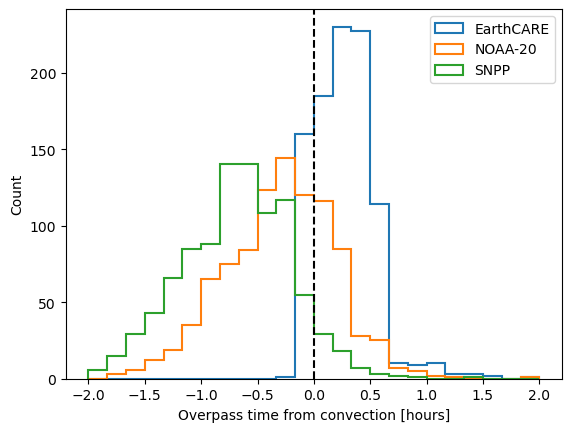

In [61]:
h1 = plt.hist(
    coloc_gdf.ec_time_offset.dt.total_seconds()/3.6e3, 
    bins=pd.timedelta_range(
        -pd.Timedelta("2h"), pd.Timedelta("2h"), freq="600s"
    ).total_seconds()/3.6e3,
    histtype="step", 
    linewidth=1.5
)

h2 = plt.hist(
    coloc_gdf.noaa_20_time_offset.dt.total_seconds()/3.6e3, 
    bins=pd.timedelta_range(
        -pd.Timedelta("2h"), pd.Timedelta("2h"), freq="600s"
    ).total_seconds()/3.6e3,
    histtype="step", 
    linewidth=1.5
)

h3 = plt.hist(
    coloc_gdf.snpp_time_offset.dt.total_seconds()/3.6e3, 
    bins=pd.timedelta_range(
        -pd.Timedelta("2h"), pd.Timedelta("2h"), freq="600s"
    ).total_seconds()/3.6e3,
    histtype="step", 
    linewidth=1.5
)

plt.gca().axvline(0, linestyle="--", color="k")

plt.legend(
    ["EarthCARE", "NOAA-20", "SNPP"]
)
plt.xlabel("Overpass time from convection [hours]")
plt.ylabel("Count")